# Credit Risk Modeling - Exploratory Data Analysis

## Introduction

The objective of this exploratory data analysis (EDA) is to understand the structure, quality, and characteristics of the Xente transaction dataset used for alternative credit scoring.

The analysis focuses on:

- Understanding dataset structure and feature types
- Exploring numerical and categorical variables
- Detecting missing values and outliers
- Investigating relationships between variables
- Identifying insights that can guide feature engineering and risk modeling

The findings from this notebook will directly inform the feature engineering and proxy target creation stages of the project.

## Data loading

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("../data/raw/data.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


#### **1. Data Loading and Initial Inspection**

#### **Analysis & Business Implications**
* **Dataset Shape & Granularity:** The raw dataset contains 95,662 rows and 16 columns, structured at the individual transaction level. Each row represents a single financial activity on the eCommerce platform.
* **Customer Tracking & Aggregation Potential:** The presence of `CustomerId` and `AccountId` is critical. Because we can see multiple transactions tied to the same user (e.g., both debits and credits for `CustomerId_4406`), we have the necessary foundation to aggregate transaction history at the user level. This will allow us to engineer behavioral metrics—such as Recency, Frequency, and Monetary value (RFM)—which are required to construct our proxy target variable for risk.
* **Financial Value & Directionality:** 
  * **Debits (`Amount > 0`):** Outflows or purchases (e.g., spending 1000.0 UGX on airtime).
  * **Credits (`Amount < 0`):** Inflows or repayments (e.g., -20.0 UGX for financial services). 
  * The `Value` column strictly captures the absolute transaction size (`abs(Amount)`). Both columns will be vital for assessing a customer's financial capacity.
* **Time & Alternative Data Signals:** The `TransactionStartTime` provides the chronological sequence needed to measure transaction recency. Additionally, categorical variables like `ProductCategory` (e.g., `utility_bill` vs. `airtime`), `ProviderId`, and the binary `FraudResult` flag provide a rich behavioral footprint. In the absence of traditional credit bureau data, these features will serve as our primary predictive signals for scoring creditworthiness.



## 1. Data Understanding

Before performing any analysis, it is important to understand the dataset structure, dimensions, feature types, and overall composition.

This section examines:

- Dataset dimensions
- Column names
- Data types
- Basic dataset information

In [2]:
df.shape

(95662, 16)

In [3]:
df.columns.tolist()


['TransactionId',
 'BatchId',
 'AccountId',
 'SubscriptionId',
 'CustomerId',
 'CurrencyCode',
 'CountryCode',
 'ProviderId',
 'ProductId',
 'ProductCategory',
 'ChannelId',
 'Amount',
 'Value',
 'TransactionStartTime',
 'PricingStrategy',
 'FraudResult']

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult        

In [5]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [6]:
df.describe(include="object")

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,ProviderId,ProductId,ProductCategory,ChannelId,TransactionStartTime
count,95662,95662,95662,95662,95662,95662,95662,95662,95662,95662,95662
unique,95662,94809,3633,3627,3742,1,6,23,9,4,94556
top,TransactionId_76871,BatchId_67019,AccountId_4841,SubscriptionId_3829,CustomerId_7343,UGX,ProviderId_4,ProductId_6,financial_services,ChannelId_3,2018-12-24T16:30:13Z
freq,1,28,30893,32630,4091,95662,38189,32635,45405,56935,17


### **1. Data Understanding & Summary Statistics**

#### **Dataset Completeness & Data Types**
* **No Missing Values:** The `df.info()` output reveals that all 16 columns have exactly 95,662 non-null entries. This is an excellent starting point, meaning we will not need to perform extensive imputation for missing data during our feature engineering pipeline.
* **Data Type Adjustments Needed:** Most features are correctly typed, but `TransactionStartTime` is currently stored as an `object` (string). To compute the "Recency" component of our RFM metrics, this must be converted to a `datetime` format. Additionally, categorical identifiers loaded as numbers (like `PricingStrategy` and `ChannelId`) should be treated as categorical variables rather than continuous numerical data.

#### **Numerical Feature Insights**
* **Transaction Amounts & Outliers:** The `Amount` and `Value` columns show massive variance. While the median transaction (`Amount` 50th percentile) is just 1,000 UGX, the maximum transaction reaches 9.88 million UGX, and the minimum drops to -1 million UGX (likely large loan repayments or merchant credits). This heavy skew indicates the presence of significant outliers, which we will need to handle (e.g., via robust scaling or logarithmic transformation) to prevent them from overly influencing our clustering and risk models.
* **Highly Imbalanced Target Proxy (`FraudResult`):** The mean for `FraudResult` is `0.002018`, indicating that only about 0.2% of the transactions are marked as fraudulent. If we plan to use this as a predictive feature or correlate it with our eventual default proxy, we must be mindful of this extreme class imbalance.
* **Zero Variance Features:** `CountryCode` has a constant value of `256` (standard deviation of 0). This feature provides no predictive power and can be safely dropped during preprocessing. 

#### **Categorical Feature Insights**
* **Customer Aggregation Viability:** Out of 95,662 transactions, there are 3,742 unique `CustomerId`s. This gives us an average of about 25.5 transactions per customer. This depth of historical data per user is highly favorable; it guarantees we have enough activity data to calculate meaningful Recency, Frequency, and Monetary (RFM) profiles for reliable risk clustering.
* **Dominant Categories:** 
  * The most frequent `ProductCategory` is `financial_services`, accounting for nearly half of all transactions (45,405). This suggests a user base already actively engaging with financial products.
  * The primary transaction channel is `ChannelId_3` (56,935 transactions), and the top provider is `ProviderId_4`.
* **Zero Variance (Categorical):** Similar to `CountryCode`, `CurrencyCode` only contains a single unique value (`UGX`). This can also be removed from our modeling features.


## 2. Data Cleaning Checks

Data quality directly impacts model performance.

This section evaluates:

- Duplicate records
- Invalid data types
- Basic consistency checks

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

In [9]:
df.nunique().sort_values(ascending=False)

TransactionId           95662
BatchId                 94809
TransactionStartTime    94556
CustomerId               3742
AccountId                3633
SubscriptionId           3627
Amount                   1676
Value                    1517
ProductId                  23
ProductCategory             9
ProviderId                  6
ChannelId                   4
PricingStrategy             4
FraudResult                 2
CurrencyCode                1
CountryCode                 1
dtype: int64

### **2. Data Cleaning Checks**

#### **Analysis & Data Quality Implications**
* **Duplicate Records:** There are **0 duplicate rows** in the dataset. This indicates strong transactional data integrity from the Xente platform platform, meaning we do not need to worry about artificially inflated transaction frequencies or volumes during our RFM calculations.
* **Missing Values:** Reconfirming our initial inspection, there are **0 missing values** across all columns. This significantly streamlines our Task 3 feature engineering pipeline, as we will not need to design complex imputation strategies for the raw data components.
* **Cardinality & Feature Engineering Groupings:** Sorting the unique value counts provides a clear roadmap for feature processing:
  * **Primary Keys:** `TransactionId` is perfectly unique (95,662), serving as the definitive primary key for the dataset. 
  * **Customer Entities:** `CustomerId` (3,742 unique) and `AccountId` (3,633 unique) have very similar counts, confirming the user base size. We will aggregate at the `CustomerId` level to build our proxy risk variable.
  * **Categorical Features (Low Cardinality):** `ProductId` (23), `ProductCategory` (9), `ProviderId` (6), `ChannelId` (4), and `PricingStrategy` (4) have very manageable unique counts. These are ideal candidates for One-Hot Encoding or Weight of Evidence (WoE) transformations in our machine learning pipeline. 
  * **Constant Features to Drop:** `CurrencyCode` and `CountryCode` both have exactly 1 unique value. They offer zero variance and zero predictive power for a machine learning model. These must be dropped to reduce dimensionality and noise.


## 3. Univariate Analysis

This section explores the distribution of individual variables independently.

Understanding feature distributions helps identify:

- Skewness
- Extreme values
- Class imbalance
- Data quality issues

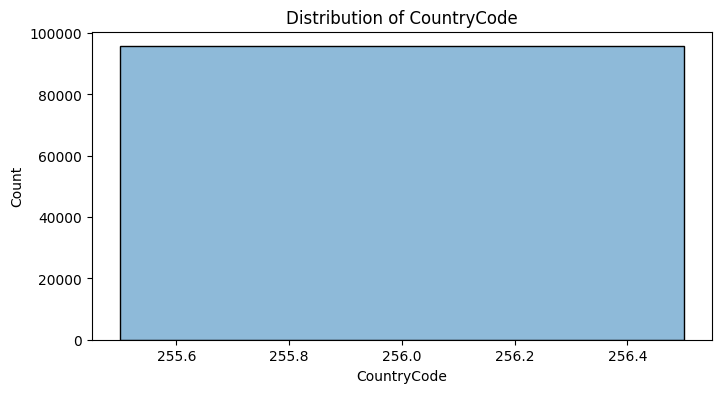

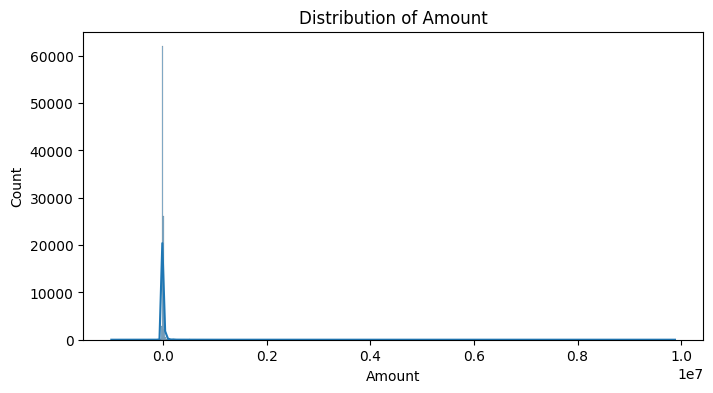

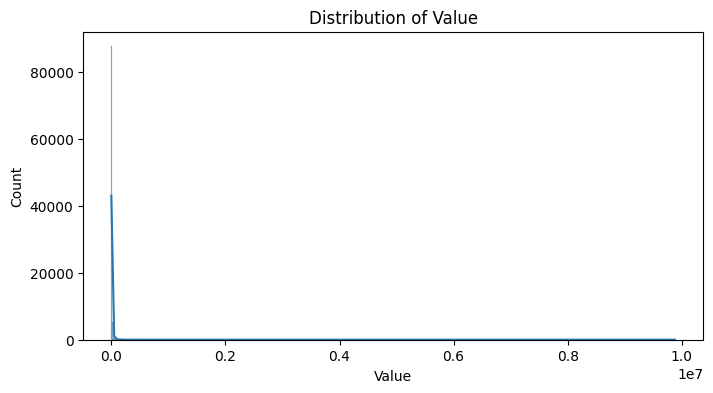

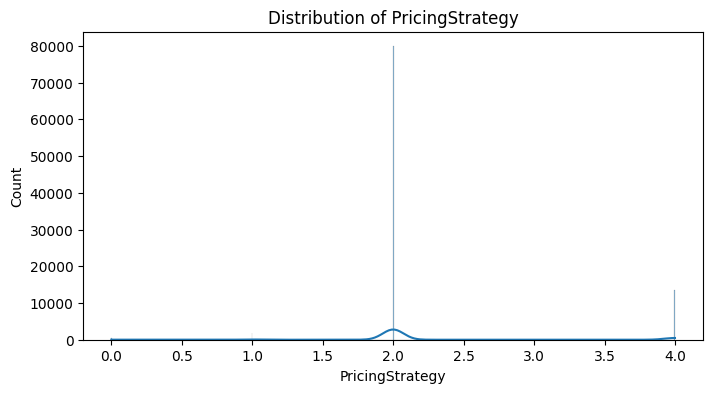

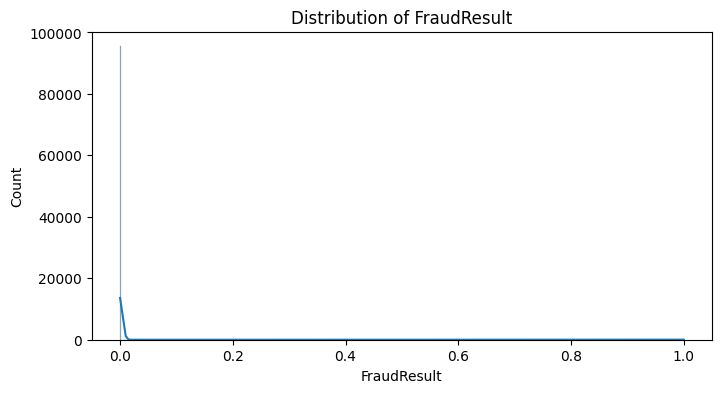

In [10]:
numerical_cols = df.select_dtypes(include=np.number).columns

numerical_cols

for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

### **3. Univariate Analysis: Numerical Features**

#### **Analysis & Distribution Insights**

* **Extreme Skewness in Financial Variables (`Amount` & `Value`):** 
  The histograms for both `Amount` and `Value` show extreme leptokurtic distributions (highly peaked around zero with very long tails). Most transaction values are quite small, but there are massive outliers (up to 9.88 million UGX). 
  * *Modeling Implication:* Machine learning models like Logistic Regression are highly sensitive to outliers. To ensure our credit risk model remains stable, we must apply robust scaling techniques or logarithmic transformations (e.g., `np.log1p()`) to these financial features during our feature engineering pipeline (Task 3).
  
* **Discrete/Categorical Variables Stored as Numeric (`PricingStrategy` & `FraudResult`):**
  * **`PricingStrategy`:** The plot shows discrete spikes at specific integer values (0, 1, 2, and 4) rather than a continuous curve. A vast majority of transactions fall under a single strategy (Category 2). This confirms that this feature is strictly categorical and should be encoded (e.g., One-Hot or Weight of Evidence) rather than scaled numerically.
  * **`FraudResult`:** The histogram visualizes the massive class imbalance identified earlier. Almost the entire distribution is stacked at `0` (non-fraud), with barely a visible tick at `1` (fraud). When we eventually train our models, we will need to utilize appropriate evaluation metrics (like PR-AUC or F1-Score instead of simple Accuracy) and consider techniques like SMOTE or class weighting.

* **Constant Value Confirmation (`CountryCode`):** 
  The plot for `CountryCode` shows a single massive pillar at `256`. As observed in the summary statistics, a zero-variance feature offers no discriminative power to separate high-risk from low-risk customers. This feature will be removed in the preprocessing phase.


## Categorical Features

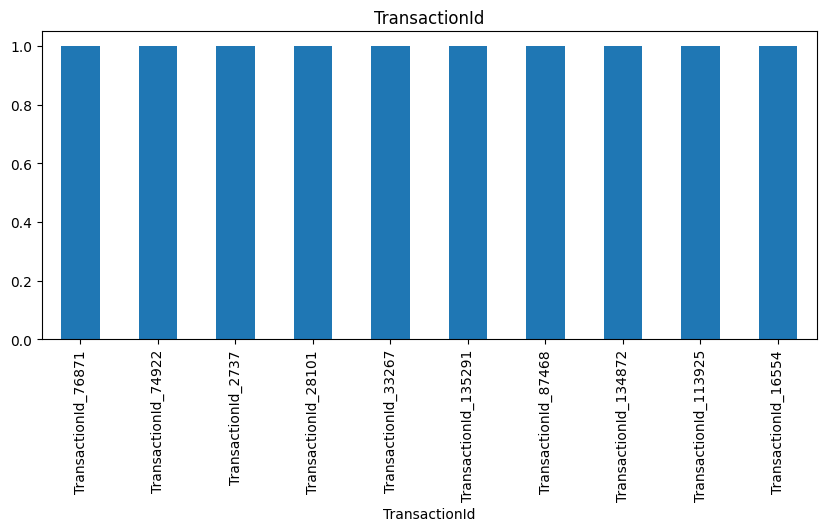

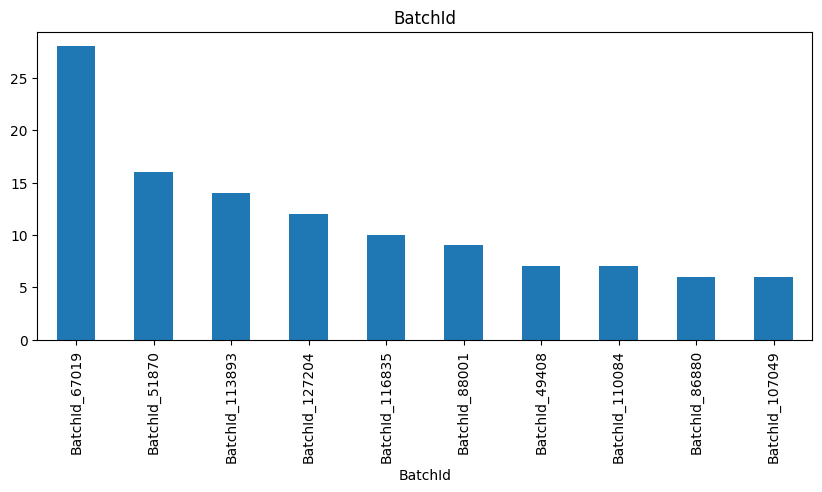

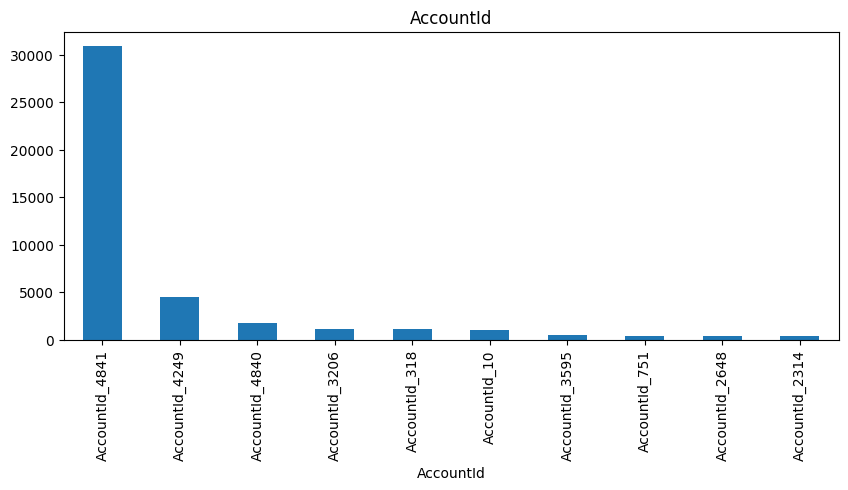

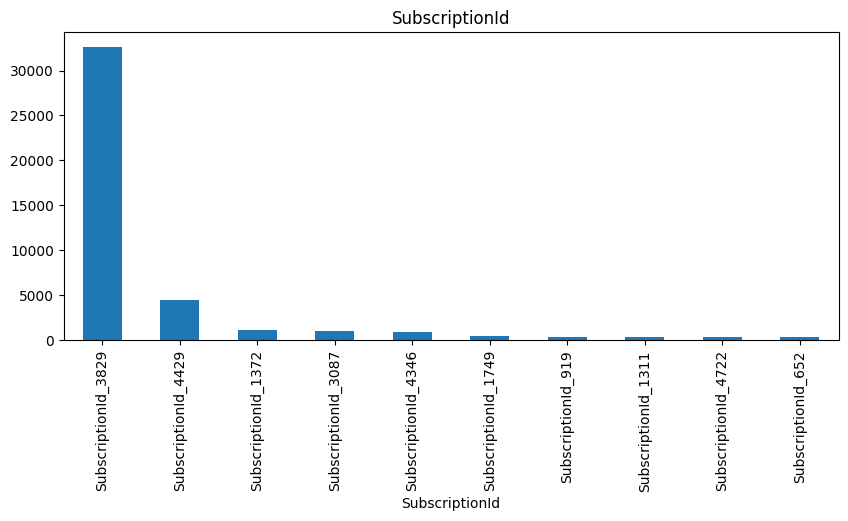

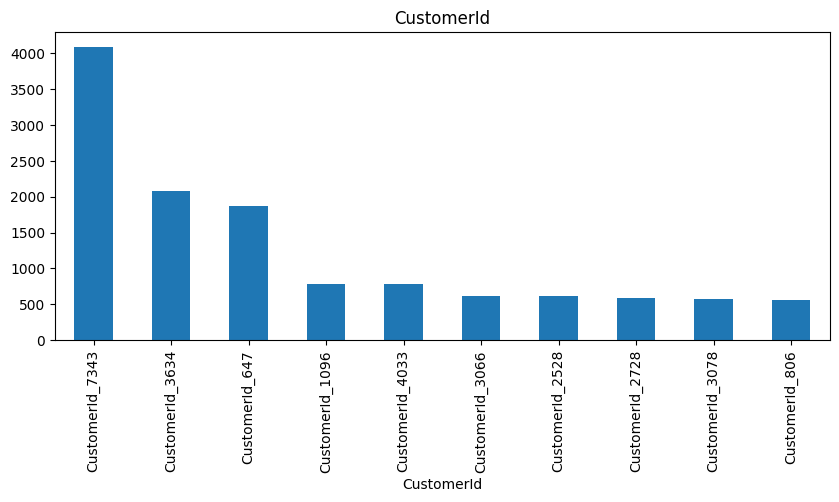

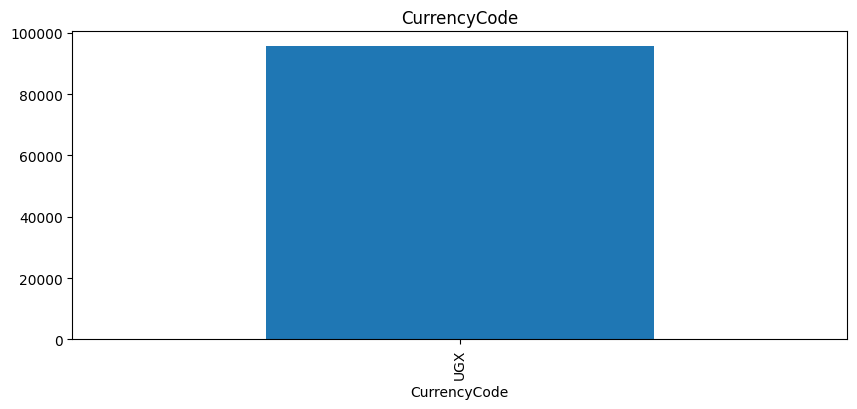

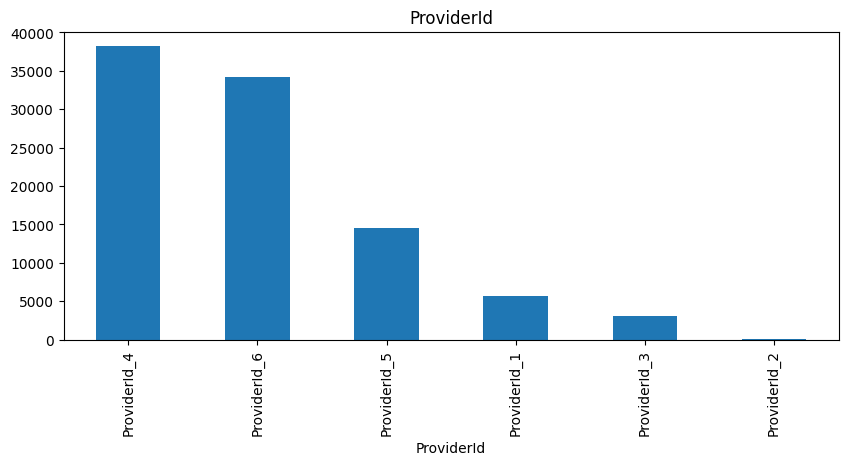

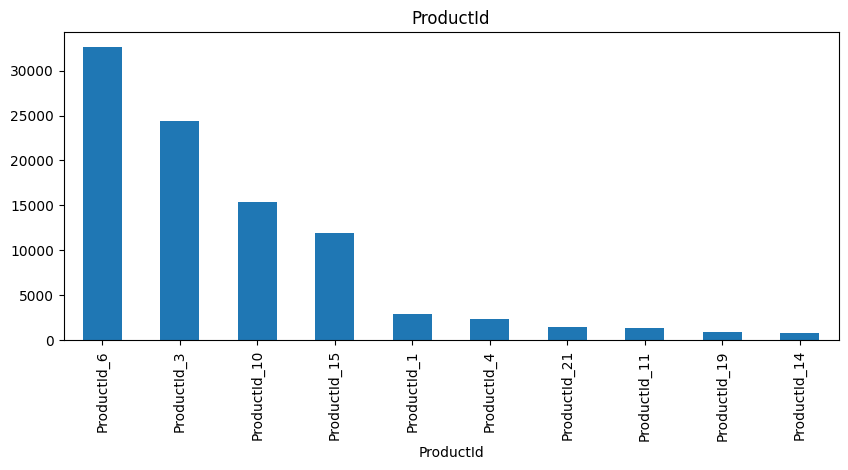

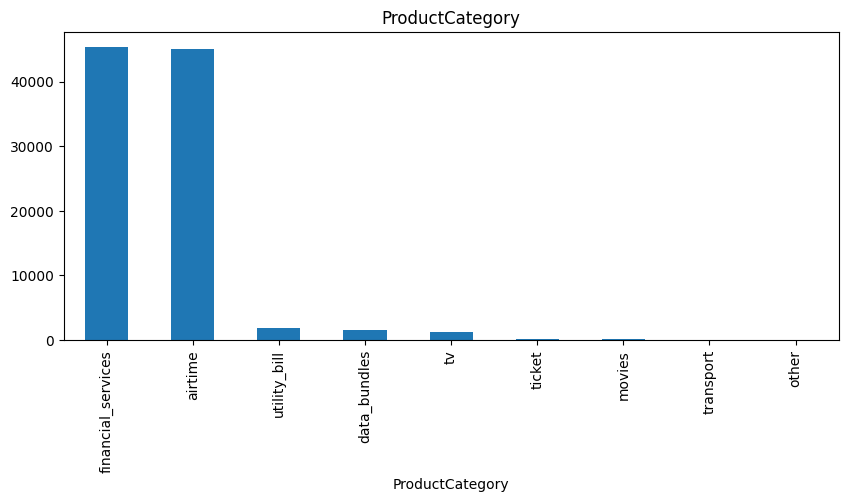

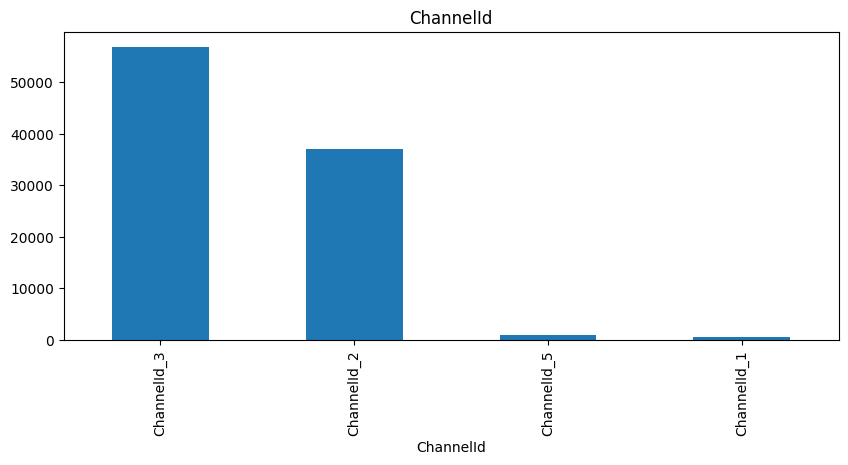

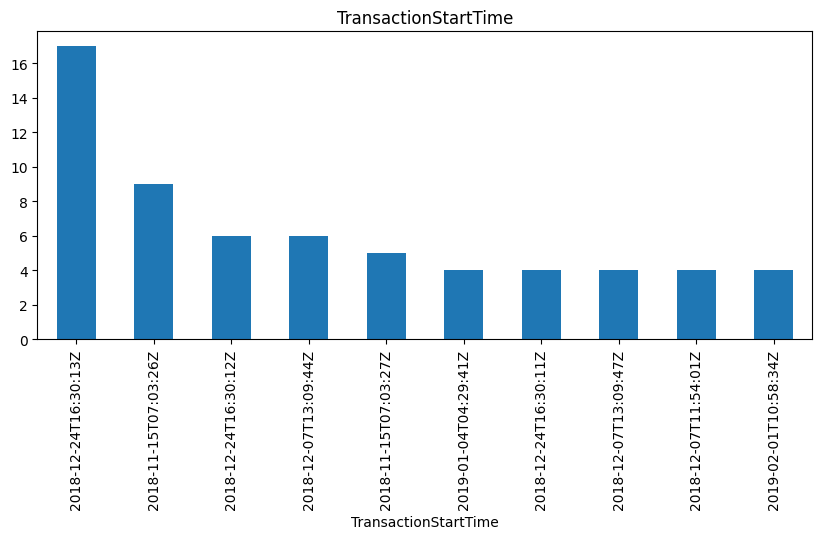

In [11]:
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols

for col in categorical_cols:
    plt.figure(figsize=(10,4))
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(col)
    plt.show()

### **3. Univariate Analysis: Categorical Features**

#### **Analysis & Behavioral Insights**

* **High-Frequency 'Power Users' (Customer & Account IDs):** 
  The bar charts for `CustomerId`, `AccountId`, and `SubscriptionId` reveal a steep drop-off after the top few entities. This indicates the presence of "power users" who transact exponentially more often than the average customer. 
  * *Modeling Implication:* This variance in user activity is exactly what we need to calculate a meaningful "Frequency" metric for our RFM clustering. It ensures our user base is diverse enough to segment into distinct low-risk and high-risk profiles.

* **Behavioral Predictors (`ProductCategory`, `ProductId`, & `ProviderId`):**
  These columns represent our core "alternative data" features, acting as proxies for user financial behavior:
  * **Product Category:** The distribution is heavily skewed toward `financial_services` and `airtime`, with other categories like `utility_bill` or `data_bundles` appearing much less frequently. The type of product a user consistently buys can be a strong indicator of financial stability (e.g., paying utility bills vs. only purchasing micro-airtime).
  * **Provider & Product IDs:** A few specific providers and products dominate the platform's volume. 
  * *Modeling Implication:* Because these categorical features exhibit clear majority and minority classes, they will be highly valuable when transformed using Weight of Evidence (WoE). WoE will effectively map these categorical preferences into continuous risk scores based on how they correlate with our eventual high-risk target.

* **Platform Engagement (`ChannelId`):** 
  Engagement is largely concentrated in a single channel (likely Android or Web, based on typical eCommerce patterns), with a secondary channel also showing significant volume. How a user interacts with the platform might subtly correlate with their demographic or risk profile.

* **High-Cardinality & Zero-Variance Features:**
  * **Time & Batch:** `TransactionStartTime` and `BatchId` are highly unique. While not directly useful as categorical predictors in their raw string format, `TransactionStartTime` will be engineered to extract temporal features (Hour, Day, Month) and Recency.
  * **Currency:** As confirmed earlier, `CurrencyCode` only contains `UGX`. The plot reinforces that it provides no variance and must be dropped.


## 4. Bivariate Analysis

This section investigates relationships between pairs of variables.

The objective is to identify patterns that may influence customer risk behavior and feature importance.

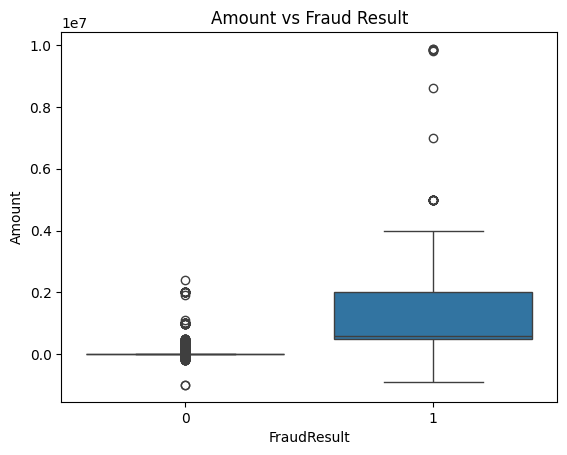

In [12]:
sns.boxplot(
    x="FraudResult",
    y="Amount",
    data=df
)

plt.title("Amount vs Fraud Result")
plt.show()

### **4. Bivariate Analysis: Amount vs. Fraud Result**

#### **Analysis & Behavioral Insights**

* **Disparity in Transaction Scales:** 
  The boxplot comparing `Amount` against `FraudResult` highlights a distinct behavioral difference between normal transactions (Class 0) and fraudulent ones (Class 1). While the vast majority of non-fraudulent transactions are clustered near zero, fraudulent transactions often exhibit significantly larger monetary values. This aligns with standard risk typologies where bad actors attempt to extract maximum value before detection.
* **Directionality of Fraud:** 
  Normal transactions show extreme outliers in both the positive (debits/purchases) and negative (credits/refunds) directions. In contrast, fraudulent activity is predominantly skewed toward large positive amounts (outflows).
* **Modeling Implication:** 
  The absolute size of a transaction (`Value` or `Amount`) will likely be a strong predictive feature. However, the extreme visual compression of the boxes due to massive outliers (reaching nearly 10 million UGX) reiterates our earlier finding: **we must apply robust scaling or logarithmic transformations** to the financial columns during feature engineering. If left unscaled, these massive outliers will distort distance-based clustering algorithms (K-Means) and gradient-based classification models.


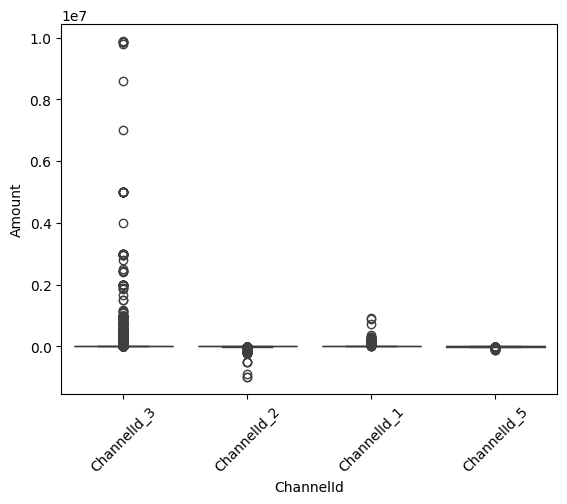

In [13]:
sns.boxplot(
    x="ChannelId",
    y="Amount",
    data=df
)

plt.xticks(rotation=45)
plt.show()

### **4. Bivariate Analysis: Transaction Amount by Channel**

#### **Analysis & Behavioral Insights**

* **Channel-Specific Transaction Behavior:** 
  The boxplot mapping `Amount` across different `ChannelId`s reveals drastically different usage patterns based on the platform channel. 
  * **ChannelId_3** is the dominant conduit for high-value transactions, containing extreme outliers that reach up to nearly 10 million UGX. This channel likely handles major purchases or bulk transfers.
  * **ChannelId_2** shows moderate transaction sizes, while **ChannelId_1** and **ChannelId_5** are tightly compressed near zero, indicating they are almost exclusively used for micro-transactions or low-value activities.
* **Risk & Modeling Implications:** 
  Since we observed earlier that fraudulent or high-risk activity is often associated with larger transaction amounts, `ChannelId_3` naturally carries a higher risk exposure due to its volume capacity. 
  * *Feature Engineering:* `ChannelId` will be a highly valuable categorical feature. Furthermore, calculating interaction features during Task 3—such as the *average transaction amount per channel per customer*—could provide strong behavioral signals for our credit scoring model, as a sudden spike in high-value transactions on a specific channel might indicate a shift in a user's risk profile.


## 5. Correlation Analysis

Correlation analysis helps identify linear relationships between numerical variables.

Strong correlations may indicate:

- Redundant information
- Potential multicollinearity
- Useful predictive relationships

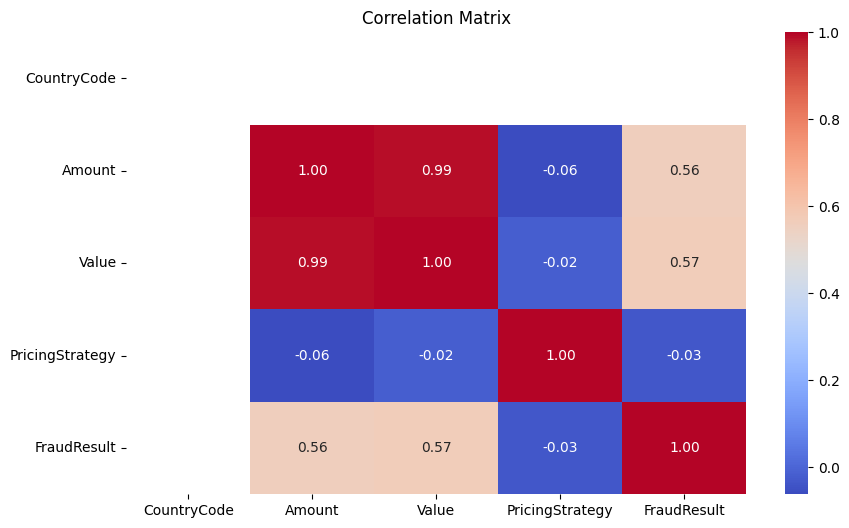

In [14]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### **. Correlation Analysis (Heatmap Review)**

#### **Analysis & Statistical Insights**

* **Perfect Multicollinearity (`Amount` & `Value`):** 
  The heatmap confirms an almost perfect correlation (**0.99**) between `Amount` and `Value`. Since `Value` is the absolute magnitude of `Amount`, this is mathematically expected. 
  * *Modeling Implication:* Retaining both raw features in linear models (like Logistic Regression) will cause severe multicollinearity, distorting feature weights. During feature engineering, we must either drop one or engineer specific aggregated features (e.g., separating total inflows vs. total outflows) to capture the financial behavior without redundancy.
* **Strong Signal for Risk (`Value`/`Amount` & `FraudResult`):** 
  Remarkably, despite extreme class imbalance, there is a very strong positive correlation between transaction size (`Value` at **0.57**, `Amount` at **0.56**) and `FraudResult`. This mathematically validates our earlier visual observations: large transaction volumes are a primary indicator of anomalous, high-risk behavior. This will be a cornerstone feature when building our credit scoring model.
* **Zero Variance Confirmation (`CountryCode`):** 
  `CountryCode` shows `NaN` correlations across the board. The mathematical formula for Pearson correlation involves dividing by standard deviation; since `CountryCode` is a constant (std = 0), the calculation fails. This is final confirmation to drop the column.
* **Weak Linear Relationships for Categories:** 
  `PricingStrategy` shows near-zero correlation with all other variables (e.g., **-0.03** with `FraudResult`). However, this does not mean it lacks predictive power—it simply means the relationship is not *linear*. Categorical encoding techniques like Weight of Evidence (WoE) will be required to unlock its true predictive value.


## 6. Missing Value Analysis

Missing values can introduce bias and reduce model performance.

This section identifies missingness patterns and potential remediation strategies.

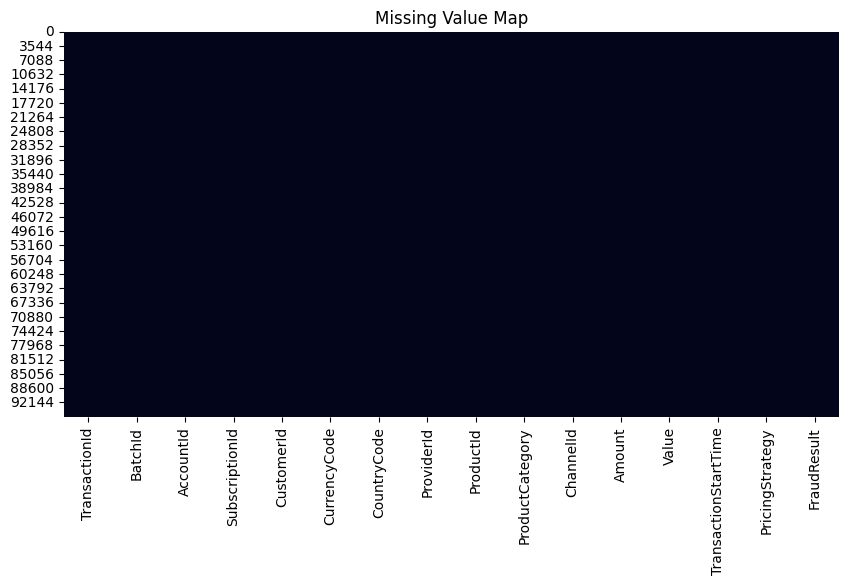

In [15]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Value Map")
plt.show()

### **Missing Value Analysis**

#### **Analysis & Data Quality Implications**

* **Flawless Data Completeness:** 
  The `df.isnull().sum()` output and the uniformly solid heatmap confirm that there are **zero missing values** across all 95,662 rows and 16 columns. 
* **Modeling Implication:** 
  This is an exceptionally clean dataset, reflecting highly structured backend logging by the Xente platform. From a data engineering perspective, this drastically simplifies our Task 3 feature engineering pipeline. We will not need to introduce statistical biases through imputation techniques (e.g., mean/median fills or KNN imputation), nor will we lose valuable transactional history by dropping rows. We can confidently proceed directly to aggregating RFM metrics and encoding categorical features.


## 7. Outlier Detection

Outliers are common in financial transaction data and may represent:

- Genuine high-value transactions
- Data entry errors
- Fraudulent activity

Identifying them helps determine appropriate preprocessing strategies.

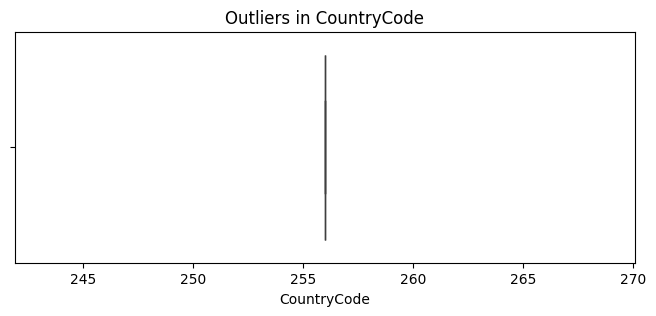

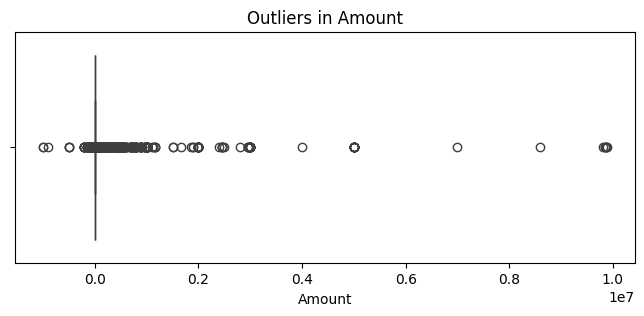

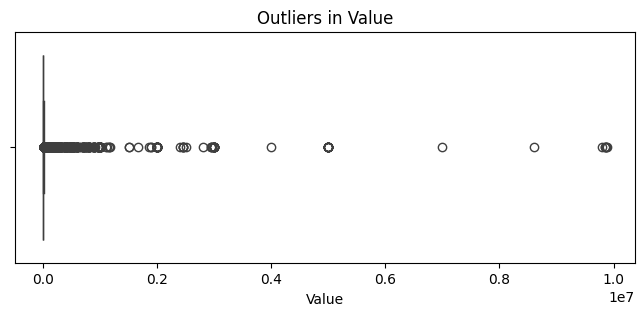

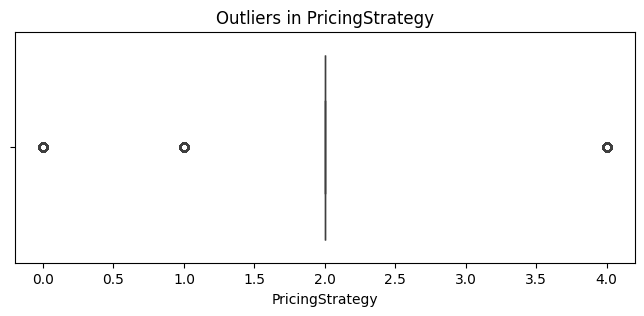

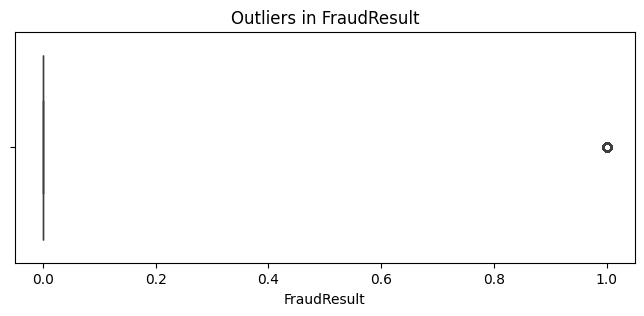

In [16]:
for col in numerical_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

### **8. Outlier Detection**

#### **Analysis & Data Quality Implications**

* **Extreme Financial Variance (`Amount` & `Value`):** 
  The boxplots for both `Amount` and `Value` are completely compressed near the zero mark, with outlier points extending massively to the right (up to ~10 million UGX) and to the left for `Amount` (down to -1 million UGX). While standard statistical rules flag these as "outliers," in eCommerce and banking, these are typically genuine high-value events (e.g., corporate transfers, merchant disbursements, or bulk payments) rather than data entry errors. 
  * *Modeling Strategy:* We cannot drop these records, as they represent significant financial behaviors. Instead, we will handle them during Task 3 using non-linear transformations (like `np.log1p()`) or robust scaling techniques (like `RobustScaler`) to normalize the data spread before feeding it into our clustering and classification models.

* **Categorical Variables Represented as Numeric (`PricingStrategy`):** 
  The boxplot for `PricingStrategy` shows a single thick line at `2`, with other categories appearing statistically as "outliers." Because this variable is categorical rather than continuous, calculating an interquartile range (IQR) isn't conceptually valid. This simply reinforces that the vast majority of transactions use Strategy 2, and the feature must be explicitly cast and encoded as categorical during preprocessing.

* **Visualizing Class Imbalance (`FraudResult`):** 
  The `FraudResult` boxplot perfectly illustrates our severe class imbalance. The entire box and whiskers are situated at `0` (non-fraud), meaning the IQR is zero. Consequently, every single fraud case (`1`) is flagged statistically as an "outlier." When building our credit scoring models, we must remember that our predictive target will likely suffer from similar imbalance, requiring specialized evaluation metrics like F1-Score or ROC-AUC instead of standard accuracy.

* **Zero Variance Confirmation (`CountryCode`):** 
  The specific boxplot generated for `CountryCode` shows a single, infinitely thin line at exactly 256. Because there is no data spread whatsoever, there are no statistical outliers. This serves as our final visual confirmation that this feature is a constant and must be removed prior to modeling.


## **9. Top 4 Exploratory Data Analysis Insights**

Based on the univariate, bivariate, and correlation analyses conducted above, here are the foundational insights that will directly drive our feature engineering (Task 3) and proxy target creation (Task 4):

**1. Pristine Data Quality & High RFM Viability**
* **Finding:** The dataset is exceptionally clean, containing exactly zero missing values and zero duplicate records. Crucially, there are ~95,000 transactions distributed across ~3,740 unique `CustomerId`s. 
* **Actionable Next Step:** This transactional depth provides the perfect foundation to aggregate data at the customer level. We have all the necessary components (`TransactionStartTime`, `TransactionId`, and `Amount`) to accurately compute **Recency, Frequency, and Monetary (RFM)** profiles, which will serve as the mathematical basis for our K-Means clustering to identify high-risk users.

**2. Severe Skewness and Legitimate Financial Outliers**
* **Finding:** Financial features (`Amount` and `Value`) are heavily compressed near zero but feature massive, legitimate outliers (reaching up to 9.88 million UGX), largely driven by `ChannelId_3`. 
* **Actionable Next Step:** Distance-based algorithms (like K-Means for our proxy target) and linear classification models (like Logistic Regression) are highly sensitive to unscaled outliers. During feature engineering, we must apply robust scaling or logarithmic transformations (e.g., `np.log1p()`) to normalize these financial distributions.

**3. Multicollinearity and Zero-Variance Dimensionality**
* **Finding:** The correlation matrix revealed a near-perfect linear relationship (0.99) between `Amount` and `Value`. Furthermore, `CountryCode` and `CurrencyCode` possess zero variance (only a single unique value across all 95,662 rows).
* **Actionable Next Step:** To prevent multicollinearity from distorting feature importance, we will strategically decouple `Amount` and `Value` (e.g., engineering "Total Inflows" vs. "Total Outflows" per customer). Zero-variance columns will be immediately dropped to reduce noise and dimensionality.

**4. Transaction Magnitude as a Strong Risk Signal Amidst Class Imbalance**
* **Finding:** Despite severe class imbalance (only ~0.2% of transactions are marked as fraud), there is a strong positive correlation (~0.57) between transaction `Value` and the `FraudResult`. Fraudulent or anomalous behaviors skew heavily toward large monetary outflows.
* **Actionable Next Step:** The absolute magnitude of a user's transactions will be one of our strongest predictive features for credit scoring. However, because our risk target will be highly imbalanced, we must utilize Weight of Evidence (WoE) encoding for our categorical variables and rely on metrics like ROC-AUC and F1-Score rather than simple accuracy to evaluate our final models.
